# 6.4.2 清除曲线的网格估计

## 学习目标与先修知识

能在给定的有限候选集合中估计清除系数（elimination rate constant），区分网格最优与连续最优；由误差尺度设计加权最小二乘（weighted least squares，WLS），解释对数变换改变了误差模型（model）。

先修：6.4.1 的残差（residual）与似然（likelihood）、2.3 的无输入（input）指数衰减。[复习上一节](01-最小二乘与误差假设.ipynb)。

## 具体问题

一次投放后停止输入，若各时刻的读数并不恰好落在一条指数曲线上，怎样估计清除速度？晚期读数更不精确时，给所有读数同样分量是否合理？把所追踪物质总量（tracked amount）取对数再拟合直线是否仍回答同一个问题？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GRAY = '#008bfb', '#ff0051', '#555555'

## 初步实验

In [2]:
times=[0.,1.,2.,3.,4.,5.]
observed=[10.1,6.7,5.0,3.0,2.5,1.1]
rows=[]
for k in [0.2,0.4,0.6]:
    sse=sum((y-10*math.exp(-k*t))**2 for t,y in zip(times,observed))
    rows.append((k,sse))
display(Markdown(show_table(['候选 k / T⁻¹','平方残差和 / U²'],rows)))

| 候选 k / T⁻¹ | 平方残差和 / U² |
| --- | --- |
| 0.2 | 21.9371 |
| 0.4 | 0.56249 |
| 0.6 | 10.1451 |

## 模型假设

无输入清除模型 $A(t)=A_0e^{-kt}$，已知投放后真初值（initial condition） $A_0=10$ U；$k\ge0$ 单位 $1/T$；$t_i$ 单位 T。读数 $y_i=A(t_i)+\varepsilon_i$，误差相互独立且零均值。表中六个数为固定人工观测（observation）例；初值 A₀ 是外部给定的模型条件，**不是**拿带误差的 $y_0=10.1$ U 偷换。

估计时只读取 times、observed、initial 和预先规定的候选 k、权重。示例等精度用权重 1，另一个对照把后两个点的权重减为 1/4，表示其误差标准差（standard deviation）是其余点的两倍。权重假设来自测量精度设定，不能看哪个点“妨碍拟合”就随意降权。

## 数学解释与推导

### 非线性参数也能先用有限比较

定义 $r_i(k)=y_i-A_0e^{-kt_i}$，给定正权重 $w_i$，比较
$$S_w(k)=\sum_iw_i r_i(k)^2,\qquad\hat k_{\mathcal K}=\arg\min_{k\in\mathcal K} S_w(k).$$
当候选集合 $\mathcal K$ 有限，逐个计算就能找到集合内最小值，不必先学高级优化。若有精确并列，约定选较小 k。这是并列时的选择约定，两者在当前数据上的损失仍然相同。

加密网格只可能改善或保持嵌套候选集的最小损失，并不能保证估计已等于连续范围的最优。若最优点落在端点，需要扩大候选范围再检查。对所有观测时刻 $t_i=0$，预测恒为 A₀，每个 k 损失相同，清除速度完全不可辨识。实现也允许 $A_0=0$ 的边界：无输入时任何 k 都预测零，所有候选损失相同，仍按较小 k 返回。此时的返回值由并列规则确定。

独立高斯误差（Gaussian error） $\varepsilon_i\sim N(0,\sigma_i^2)$ 的负对数似然（去掉与 k 无关的项）为 $\tfrac12\sum_i r_i(k)^2/\sigma_i^2$；因此权重应与误差方差（variance）的倒数成比例。本节采用**相对**权重，无单位，S_w 单位 U²；若直接使用 $1/\sigma_i^2$，损失则无单位。所有权重乘同一正数不会改变最优 k，但会改变损失数值。

### 对数直线意味着另一种误差

本小节的对数比较要求 $A_0>0$。无误差时 $\log A(t)=\log A_0-kt$。然而若 $y=A+\varepsilon$ 为加性误差，即使 y>0，也有
$$\log y=\log A+\log(1+\varepsilon/A)\approx\log A+\varepsilon/A,$$
近似误差方差为 $\sigma^2/A^2$，低总量的误差被放大，均值也未必为零。对数必须作用于无量纲（dimensionless）比值，写为 $\log(y/A_0)$ 更明确；y≤0 时还无法取对数。为使算法运行而删掉负读数，会改变抽样分布（distribution），不是无代价修复。

只有另行假设乘性模型 $y=A\exp(\eta)$、独立同方差（homoscedasticity） $\eta\sim N(0,\tau^2)$ 时，对数域的无权平方残差才对应这个模型的高斯误差拟合。此时 A 是 y 的中位数曲线，均值为 $A\exp(\tau^2/2)$，不能不说明就当成同一个均值模型。

## 核心实现

把每个量的计算写在本节，返回普通数值与列表；先检查定义，再用独立关系核对结果。

In [3]:
def fit_clearance_grid(times: list[float], observed: list[float], initial: float,
                       candidates: list[float], weights: list[float]
                       ) -> tuple[float, list[float], list[float], float]:
    if not times or len(times) != len(observed) or len(times) != len(weights):
        raise ValueError('时间、读数、权重须等长且非空')
    if initial < 0 or not candidates or any(k < 0 for k in candidates):
        raise ValueError('初值须非负，候选清除系数须非负且非空')
    if any(t < 0 for t in times) or any(w <= 0 for w in weights):
        raise ValueError('时间须非负，权重须为正')
    best = None
    for k in sorted(set(candidates)):
        predicted = [initial*math.exp(-k*t) for t in times]
        residuals = [y-p for y,p in zip(observed,predicted)]
        loss = sum(w*r*r for w,r in zip(weights,residuals))
        # 从较小 k 开始，只在严格改善时更新；精确并列选较小者。
        if best is None or loss < best[3]:
            best = (float(k),predicted,residuals,loss)
    return best

## 对照实验

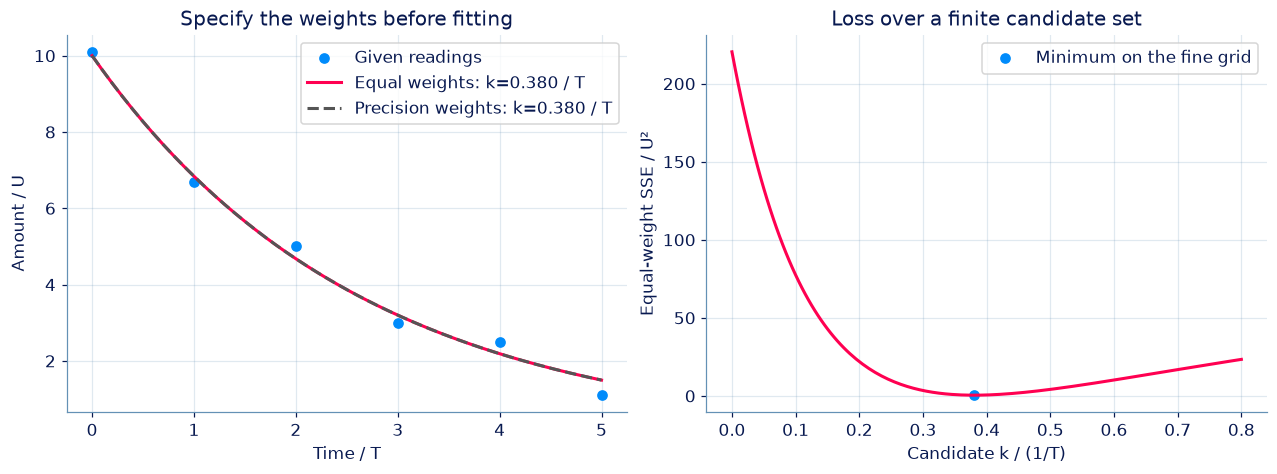

| 比较 | k / T⁻¹ | 对应损失 / U² |
| --- | --- | --- |
| 粗网格等权 | 0.4 | 0.56249 |
| 细网格等权 | 0.38 | 0.427501 |
| 细网格精度加权 | 0.38 | 0.236655 |

In [4]:
coarse=np.linspace(0.,0.8,9).tolist()
fine=np.linspace(0.,0.8,161).tolist()
equal=fit_clearance_grid(times,observed,10.,fine,[1.]*6)
weighted=fit_clearance_grid(times,observed,10.,fine,[1.,1.,1.,1.,0.25,0.25])
coarse_fit=fit_clearance_grid(times,observed,10.,coarse,[1.]*6)
losses=[fit_clearance_grid(times,observed,10.,[k],[1.]*6)[3] for k in fine]
fig,axes=plt.subplots(1,2,figsize=(11.5,4.2))
dense=np.linspace(0,5,151)
axes[0].scatter(times,observed,color=BLUE,label='Given readings')
axes[0].plot(dense,10*np.exp(-equal[0]*dense),color=PINK,label=f'Equal weights: k={equal[0]:.3f} / T')
axes[0].plot(dense,10*np.exp(-weighted[0]*dense),color=GRAY,ls='--',label=f'Precision weights: k={weighted[0]:.3f} / T')
axes[0].set(xlabel='Time / T',ylabel='Amount / U',title='Specify the weights before fitting')
axes[0].legend()
axes[1].plot(fine,losses,color=PINK)
axes[1].scatter([equal[0]],[equal[3]],color=BLUE,label='Minimum on the fine grid')
axes[1].set(xlabel='Candidate k / (1/T)',ylabel='Equal-weight SSE / U²',title='Loss over a finite candidate set')
axes[1].legend()
plt.show()
display(Markdown(show_table(['比较','k / T⁻¹','对应损失 / U²'],[
    ('粗网格等权',coarse_fit[0],coarse_fit[3]),('细网格等权',equal[0],equal[3]),
    ('细网格精度加权',weighted[0],weighted[3])])))

## 结果解释

细网格等权结果为 k=0.380/T，粗网格只含 0.1/T 的倍数，返回 0.400/T。本例改变相对权重仍选择同一个细网格点，所以两条拟合曲线重合；权重改变不保证离散最优参数（parameter）必定改变。细网格的等权损失较低，说明增加候选点改善了当前数据上的拟合。加权结果的损失定义不同，不能拿表中两个损失值的大小直接评判哪种误差模型“更好”。

### 独立核对与边界

In [5]:
# 合成精确点只用于核验实现，不作为上方拟合的隐藏答案。
test_times=[0.,1.,2.]
clean=[8*math.exp(-0.3*t) for t in test_times]
oracle=fit_clearance_grid(test_times,clean,8.,[0.1,0.3,0.5],[1.,2.,1.])
assert oracle[0]==0.3 and oracle[3]<1e-25
assert np.allclose(np.array(oracle[1])+oracle[2],clean)
tie=fit_clearance_grid([0.,0.],[10.,10.],10.,[0.6,0.2,0.4],[1.,1.])
assert tie[0]==0.2 and tie[3]==0
zero_initial=fit_clearance_grid([0.,3.],[0.1,-0.2],0.,[0.7,0.],[2.,1.])
assert zero_initial[0]==0 and zero_initial[1]==[0.,0.]
assert math.isclose(zero_initial[3],0.06)
assert equal[3] <= coarse_fit[3]+1e-12
scaled=fit_clearance_grid(times,observed,10.,fine,[7.]*6)
assert scaled[0]==equal[0] and math.isclose(scaled[3],7*equal[3])
display(Markdown('精确曲线、残差重构、无信息并列与权重尺度核对均通过。'))

精确曲线、残差重构、无信息并列与权重尺度核对均通过。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：在给定参数集合中拟合清除

模型（model）A(t)=initial*exp(−kt)，初值（initial condition）已知。比较全部候选清除系数（elimination rate constant），返回最佳参数（parameter）、拟合值、残差（residual）和损失。

**函数与代码模板**

```python
def solve(
    times: list[float],
    observed: list[float],
    initial: float,
    candidates: list[float],
    weights: list[float],
) -> tuple[float, list[float], list[float], float]:
    # 按题目定义返回计算结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `times` | `list[float]` | 无输入（input）清除开始后的观察时刻。 | T |
| `observed` | `list[float]` | 对应读数，可含测量误差。 | U |
| `initial` | `float` | 独立给定的初始所追踪物质总量（tracked amount），本题不拟合。 | U |
| `candidates` | `list[float]` | 待比较的清除系数有限集合，可以未排序或重复。 | 1/T |
| `weights` | `list[float]` | 每个读数平方残差的正的无量纲（dimensionless）相对权重。 | 1 |

**返回值**

按以下顺序返回元组：(best_k, predicted, residuals, weighted_sse)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `best_k` | `float` | 有限候选中目标最小者，完全并列选较小k。 | 1/T |
| `predicted` | `list[float]` | 在观测（observation）时刻的拟合值。 | U |
| `residuals` | `list[float]` | observed−predicted。 | U |
| `weighted_sse` | `float` | Σweights[i]*residuals[i]²。 | U² |

**计算规则**

每个k的预测为initial*exp(−k*t)。比较给定加权平方误差和；候选去重后升序扫描，只有严格更小的损失才更新。返回的最优仅限此候选集合。

**约束与边界**

- 所有非缺测数值有限；不修改输入列表。
- 等长1—30个times/observed/weights；0≤t≤20，|observed|≤30，0<weights≤100；0≤initial≤20；1—30个候选，0≤k≤2。测试非完全并列时目标差>1e−8。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| times | 无输入（input）清除开始后的观察时刻。 | [0.0, 1.0, 2.0] | T |
| observed | 对应读数，可含测量误差。 | [4.0, 2.0, 1.0] | U |
| initial | 独立给定的初始所追踪物质总量（tracked amount），本题不拟合。 | 4 | U |
| candidates | 待比较的清除系数有限集合，可以未排序或重复。 | [0.0, 0.6931471805599453, 1.0] | 1/T |
| weights | 每个读数平方残差的正的无量纲（dimensionless）相对权重。 | [1.0, 1.0, 1.0] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
times = [0.0, 1.0, 2.0]
observed = [4.0, 2.0, 1.0]
initial = 4.0
candidates = [0.0, 0.6931471805599453, 1.0]
weights = [1.0, 1.0, 1.0]

result = solve(times, observed, initial, candidates, weights)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| best_k | 有限候选中目标最小者，完全并列选较小k。 | ≈ 0.6931472 | 1/T |
| predicted | 在观测（observation）时刻的拟合值。 | [4.0, 2.0, 1.0] | U |
| residuals | observed−predicted。 | [0.0, 0.0, 0.0] | U |
| weighted_sse | Σweights[i]*residuals[i]²。 | 0 | U² |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = (0.6931471805599453,
                   [4.0, 2.0, 1.0],
                   [0.0, 0.0, 0.0],
                   0.0)
```

**样例解释**

k=ln2 时每个时间单位减半，预测 [4,2,1] U，残差全0，损失0。这不意味着任意网格总会包含真实k。

允许 Python 标准库；绝对误差 1e-09 或相对误差 1e-08。

[作答：在给定参数集合中拟合清除](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-clearance-grid)

### 第 2 题 · 多项选择题：取对数只是换一种写法吗

原测量模型（model）Y=A0*exp(−kt)+ε，其中ε是固定方差（variance）的加性高斯误差（Gaussian error）。哪些正确？

- **A.** Y≤0时对数甚至无定义，不能静默删点而不说明。
- **B.** 若误差原本是乘性对数正态，另一个对数模型可能合理。
- **C.** 直接拟合原单位平方残差（residual）符合这个误差设定。
- **D.** 对所有Y取对数再做等权直线拟合，必与原问题等价。

[作答：取对数只是换一种写法吗](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-log-error-model)

### 第 3 题 · 单项选择题：网格最优意味着什么

在k∈{0.1,0.2,0.3}中k=0.2的损失最小。哪项结论成立？

- **A.** 若最优在边界，无须考虑边界之外。
- **B.** 0.2是所有实数k中的精确最优。
- **C.** 0.2是已比较集合中的最优，需检查网格范围和分辨率。
- **D.** 网格越密就必定证明机制真实。

[作答：网格最优意味着什么](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-grid-resolution)

### 第 4 题 · 多项选择题：带噪差分为何不能当无误差导数

观测（observation）Y[n]=A[n]+ε[n]，ε独立同方差（homoscedasticity）σ²。采用(Y[n+1]−Y[n])/h近似变化率。哪些正确？

- **A.** 差分噪声方差（variance）为2σ²/h²。
- **B.** h变小同时可能放大差分噪声。
- **C.** 差分中的−ε[n]与回归量Y[n]共享误差，可能使普通回归有偏。
- **D.** 差分近似误差变小就代表总误差必变小。

[作答：带噪差分为何不能当无误差导数](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-noisy-differences)

### 第 5 题 · 多项选择题：拟合残差小还需检查什么

一个清除模型（model）在用于拟合的三次观测（observation）上误差很小。哪些后续检查合理？

- **A.** 检查残差（residual）随时间的结构与测量假设。
- **B.** 用核验真值挑参数（parameter），然后声称只用观测拟合。
- **C.** 报告参数搜索范围和可能的参数混淆。
- **D.** 在预先保留的其他时刻/个体上验证。

[作答：拟合残差小还需检查什么](http://127.0.0.1:8000/chapters/06-04-%E6%9C%80%E5%B0%8F%E4%BA%8C%E4%B9%98%E4%B8%8E%E5%8F%82%E6%95%B0%E4%BC%B0%E8%AE%A1/practice/?question=p06-residual-validation)

**进一步阅读**

[NIST：加权最小二乘](https://www.itl.nist.gov/div898/handbook/pmd/section1/pmd143.htm)：不同精度观测的权重及其限制。本节使用透明的有限候选比较，不宣称完成通用非线性优化。